In [3]:
import torch
import numpy as np
import pandas as pd

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader,TensorDataset #do koncowego przygotowania danych
import pysam
import yfinance as yf #do danych finansowych

from sklearn.preprocessing import MinMaxScaler #do skalowania

from sklearn.metrics import classification_report #do robienia raportów o uczeniu

import matplotlib.pyplot as plt

import seaborn as sns
import statsmodels.api as sm

import optuna
from optuna.trial import TrialState
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

import funkcje


device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

/opt/anaconda3/envs/DNA_projeckt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
data=yf.download("BTC-USD", start="2014-01-01", interval="1d",auto_adjust=True)
data=funkcje.funkcja_do_danych(data)


[*********************100%***********************]  1 of 1 completed


In [5]:
class autocoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, seq_len, latent_dim, dropout=0.0):
        super().__init__()
        self.seq_len = seq_len
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.latent_dim = latent_dim
        
        self.encoder_lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0)
        
        
        self.hidden_to_latent = nn.Linear(hidden_size, latent_dim)
        self.relu = nn.ReLU() 

        # --- DECODER ---
      
        self.latent_to_hidden = nn.Linear(latent_dim, hidden_size)
        
        self.decoder_lstm = nn.LSTM(
            input_size=hidden_size, # Wchodzimy stanem ukrytym
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.output_layer = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        _, (hidden_n, _) = self.encoder_lstm(x)
        last_hidden_state = hidden_n[-1]
        latent_vector = self.relu(self.hidden_to_latent(last_hidden_state))
        decoder_hidden = self.latent_to_hidden(latent_vector)
        decoder_input = decoder_hidden.unsqueeze(1).repeat(1, self.seq_len, 1)
        decoder_output, _ = self.decoder_lstm(decoder_input)
        reconstructed = self.output_layer(decoder_output)
        
        return reconstructed

    def get_latent(self, x):
        with torch.no_grad():
            _, (hidden_n, _) = self.encoder_lstm(x)
            last_hidden_state = hidden_n[-1]
            latent_vector = self.relu(self.hidden_to_latent(last_hidden_state))
        return latent_vector

In [6]:

def objective(trial):
  
    latent_dim = trial.suggest_int("latent_dim", 4, 24)
    hidden_size = trial.suggest_int("hidden_size", 32, 128)
    num_layers = trial.suggest_int("num_layers", 1, 2)
    learning_rate = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)

    SEQ_LEN = trial.suggest_int("seq_len", 15, 60)

    BATCH_SIZE = trial.suggest_categorical("batch_size", [128, 256])

    EPOCHS = 30 
    
 
    INPUT_SIZE = data.shape[1]

    split_idx = int(len(data) * 0.8)
    

    train_x_raw = data.iloc[:split_idx].values
    val_x_raw   = data.iloc[split_idx:].values


    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_x_scaled = scaler.fit_transform(train_x_raw)
    val_x_scaled   = scaler.transform(val_x_raw)


    train_seq_x, _ = funkcje.sekwencje(train_x_scaled, train_x_scaled, SEQ_LEN)
    val_seq_x, _   = funkcje.sekwencje(val_x_scaled, val_x_scaled, SEQ_LEN)

    train_tensor = torch.tensor(train_seq_x, dtype=torch.float32)
    val_tensor   = torch.tensor(val_seq_x, dtype=torch.float32)


    train_loader = DataLoader(
        TensorDataset(train_tensor, train_tensor),
        batch_size=BATCH_SIZE,
        shuffle=True, 
        num_workers=2, 
        persistent_workers=True
      
    )

    val_loader = DataLoader(
        TensorDataset(val_tensor, val_tensor),
        batch_size=BATCH_SIZE,
        shuffle=False, 
        num_workers=2,
        persistent_workers=True

    )

  
    model = autocoder(
        INPUT_SIZE, hidden_size, num_layers, SEQ_LEN, latent_dim, dropout=dropout
    ).to(device)

    optimizer = optim.AdamW(
        model.parameters(), lr=learning_rate, weight_decay=1e-5
    )
    criterion = nn.MSELoss()

 
    for epoch in range(EPOCHS):
        model.train()
        
        for x, target in train_loader:
            x = x.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)

          
            optimizer.zero_grad(set_to_none=True)
            
            output = model(x)
            loss = criterion(output, target)
            
            loss.backward()
            optimizer.step()

 
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, target in val_loader:
                x = x.to(device, non_blocking=True)
                target = target.to(device, non_blocking=True)
                
                output = model(x)
                loss = criterion(output, target)
                val_loss += loss.item()

        val_loss /= len(val_loader)

      
        trial.report(val_loss, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_loss

In [7]:
sampler = TPESampler(seed=42,multivariate=True)

study = optuna.create_study(direction="minimize",sampler=sampler,pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5))
study.optimize(objective, n_trials=30,timeout=None,gc_after_trial=True,show_progress_bar=True) 

print("Najlepszy val_loss:")
print(study.best_value)

print("\nNajlepsze hiperparametry:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")


/opt/anaconda3/envs/DNA_projeckt/lib/python3.10/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-01-02 21:23:36,500] A new study created in memory with name: no-name-21db85fd-d9b3-4972-b8f5-4a4744895af2
Best trial: 0. Best value: 0.0304032:   3%|▎         | 1/30 [00:18<08:52, 18.36s/it]

[I 2026-01-02 21:23:54,782] Trial 0 finished with value: 0.030403244774788618 and parameters: {'latent_dim': 11, 'hidden_size': 124, 'num_layers': 2, 'lr': 0.0015751320499779737, 'dropout': 0.07800932022121826, 'seq_len': 22, 'batch_size': 256}. Best is trial 0 with value: 0.030403244774788618.


Best trial: 1. Best value: 0.0135598:   7%|▋         | 2/30 [00:26<05:39, 12.13s/it]

[I 2026-01-02 21:24:02,554] Trial 1 finished with value: 0.013559755403548479 and parameters: {'latent_dim': 16, 'hidden_size': 100, 'num_layers': 1, 'lr': 0.008706020878304856, 'dropout': 0.41622132040021087, 'seq_len': 24, 'batch_size': 256}. Best is trial 1 with value: 0.013559755403548479.


Best trial: 1. Best value: 0.0135598:  10%|█         | 3/30 [00:33<04:31, 10.06s/it]

...

[I 2026-01-02 21:32:07,788] Trial 28 pruned. 


Best trial: 17. Best value: 0.0118877:  97%|█████████▋| 29/30 [08:54<00:20, 20.85s/it]

[I 2026-01-02 21:32:31,106] Trial 29 pruned. 


Best trial: 17. Best value: 0.0118877: 100%|██████████| 30/30 [09:14<00:00, 18.49s/it]

Najlepszy val_loss:
0.011887670627662114

Najlepsze hiperparametry:
latent_dim: 24
hidden_size: 128
num_layers: 1
lr: 0.003585265385699159
dropout: 0.2459927636304792
seq_len: 16
batch_size: 128


Trenuję finalny model z SEQ_LEN=16...
Epoch 0: Loss 0.07069
Epoch 10: Loss 0.01443
Epoch 20: Loss 0.01181
Epoch 30: Loss 0.01032
Epoch 40: Loss 0.00946


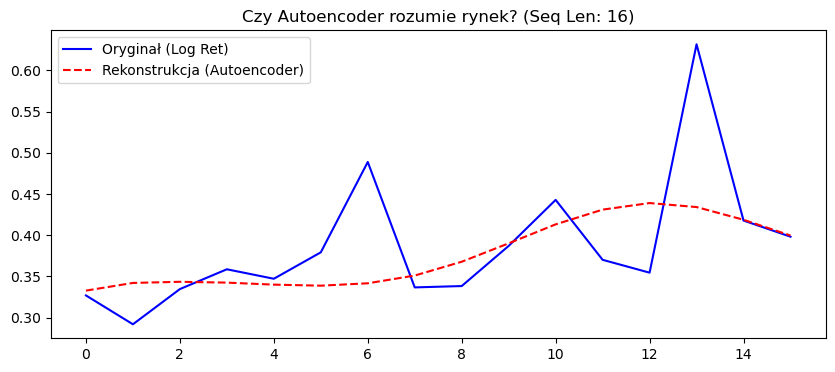

Model zapisany jako 'best_autoencoder.pth'


In [8]:
import matplotlib.pyplot as plt

best_params = study.best_params
SEQ_LEN = best_params['seq_len']
BATCH_SIZE = best_params['batch_size']

split_idx = int(len(data) * 0.8)
train_x_raw = data.iloc[:split_idx].values
val_x_raw   = data.iloc[split_idx:].values

scaler = MinMaxScaler(feature_range=(-1, 1))
train_x_scaled = scaler.fit_transform(train_x_raw)
val_x_scaled   = scaler.transform(val_x_raw)

# Generujemy sekwencje
train_seq_x, _ = funkcje.sekwencje(train_x_scaled, train_x_scaled, SEQ_LEN)
val_seq_x, _   = funkcje.sekwencje(val_x_scaled, val_x_scaled, SEQ_LEN)

# Tensors & Loaders
train_tensor = torch.tensor(train_seq_x, dtype=torch.float32)
val_tensor   = torch.tensor(val_seq_x, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(train_tensor, train_tensor), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, persistent_workers=True)
val_loader   = DataLoader(TensorDataset(val_tensor, val_tensor), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, persistent_workers=True)


final_model = autocoder(
    input_size=data.shape[1],
    hidden_size=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    seq_len=SEQ_LEN,
    latent_dim=best_params['latent_dim'],
    dropout=best_params['dropout']
).to(device)

optimizer = optim.AdamW(final_model.parameters(), lr=best_params['lr'], weight_decay=1e-5)
criterion = nn.MSELoss()


losses = []
final_model.train()
for epoch in range(50): 
    epoch_loss = 0
    for x, target in train_loader:
        x = x.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        output = final_model(x)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(train_loader))
    if epoch % 10 == 0: print(f"Epoch {epoch}: Loss {losses[-1]:.5f}")

final_model.eval()
with torch.no_grad():
    sample_input = val_tensor[0:1].to(device) 
    reconstructed = final_model(sample_input).cpu().numpy()[0] 
    original = sample_input.cpu().numpy()[0] 


plt.figure(figsize=(10, 4))
plt.plot(original[:, 0], label='Oryginał (Log Ret)', color='blue')
plt.plot(reconstructed[:, 0], label='Rekonstrukcja (Autoencoder)', color='red', linestyle='--')
plt.title(f"Czy Autoencoder rozumie rynek? (Seq Len: {SEQ_LEN})")
plt.legend()
plt.show()


torch.save(final_model.state_dict(), "best_autoencoder.pth")
print("Model zapisany jako 'best_autoencoder.pth'")

In [9]:
def get_latent_dataset(model, data_tensor, batch_size=256):
    model.eval()
    latent_features = []
    

    loader = DataLoader(TensorDataset(data_tensor), batch_size=batch_size, shuffle=False)
    
    with torch.no_grad():
        for x in loader:
            x = x[0].to(device)
        
            latent = model.get_latent(x)
            latent_features.append(latent.cpu().numpy())
            
    return np.concatenate(latent_features, axis=0)

full_x_scaled = scaler.transform(data.values) 
full_seq_x, _ = funkcje.sekwencje(full_x_scaled, full_x_scaled, SEQ_LEN)
full_tensor = torch.tensor(full_seq_x, dtype=torch.float32)

X_latent = get_latent_dataset(final_model, full_tensor)


print(f"Stare dane: {full_tensor.shape} (Batch, Czas, Cechy)")
print(f"Nowe dane dla Tradera: {X_latent.shape} (Batch, 22 cechy ukryte)")

Stare dane: torch.Size([4062, 16, 6]) (Batch, Czas, Cechy)
Nowe dane dla Tradera: (4062, 24) (Batch, 22 cechy ukryte)


In [26]:
y_final=data['log_ret'].shift(-1).dropna()
y_final=np.where(y_final>0,1,0)
y_final=y_final[SEQ_LEN-1:]
x_final=X_latent[:-1]

print(len(y_final))
print(x_final.shape)


4061
(4061, 24)


In [27]:
print(x_final,y_final)

[[0.43265963 0.14638747 0.08588816 ... 0.06494911 0.         0.00305825]
 [0.4989344  0.14332071 0.0845392  ... 0.03734275 0.09057771 0.02459846]
 [0.5643955  0.14499444 0.079912   ... 0.02114072 0.2182971  0.06113419]
 ...
 [0.2315407  0.38405257 0.         ... 0.33085778 0.16976005 0.35549176]
 [0.21943273 0.33112875 0.         ... 0.33388546 0.12556137 0.36920863]
 [0.2012564  0.30191848 0.         ... 0.32993403 0.07781913 0.40406615]] [0 1 1 ... 0 1 1]


In [28]:
np.savez_compressed('dane.npz', X=x_final, Y=y_final)